## Optimize-Backtest

In [44]:
import pandas as pd
import edhec_risk_kit as erk
import numpy as np
from scipy.optimize import minimize
%matplotlib inline
%load_ext autoreload
%autoreload 2
    
ind_return = erk.get_ind_returns()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
rets1= erk.annualized_returns(ind_return["2009":"2013"], 12)
rets2= erk.annualized_returns(ind_return["2013":"2018"], 12)
n=rets1.shape[0]
cov1 = ind_return["2009":"2013"].cov()
cov2 = ind_return["2013":"2018"].cov()
rf=0.03

In [28]:
w_eq = np.repeat (1/n, n)
w_msr = erk.msr(rets1, cov1, rf)
w_gmv = erk.gmv(cov1)

In [30]:
[erk.portfolio_return(w_eq, rets1), erk.portfolio_vola(w_eq, cov1)]

[np.float64(0.20603843825783164), np.float64(0.054229277376526865)]

In [31]:
[erk.portfolio_return(w_msr, rets1), erk.portfolio_vola(w_msr, cov1)]

[np.float64(0.22960681554485698), np.float64(0.03675282573060544)]

In [32]:
[erk.portfolio_return(w_gmv, rets1), erk.portfolio_vola(w_gmv, cov1)]

[np.float64(0.16545938680783334), np.float64(0.029876309416126)]

In [36]:
rets_out = ind_return["2013":"2018"]
# Calculate monthly returns for each
p_eq = rets_out @ w_eq
p_msr = rets_out @ w_msr
p_gmv = rets_out @ w_gmv
# Combine into single dataframe
out_perf = pd.DataFrame({
    "Equally Weighted" : p_eq,
    "Max Sharpe Ratio" : p_msr,
    "Global Min Var" : p_gmv
})

In [37]:
out_perf.head()

,Equally Weighted,Max Sharpe Ratio,Global Min Var
2013-01,0.055537,0.056624,0.053073
2013-02,0.007740,0.019183,0.036022
2013-03,0.039850,0.040514,0.058573
2013-04,0.009347,0.025446,0.034919
2013-05,0.023170,0.002038,-0.029822


In [38]:
ann_ret = erk.annualized_returns(out_perf, 12)
ann_vol = erk.annualized_volatility(out_perf, 12)
sharpe = erk.sharpe_ratio(out_perf, rf, 12)
# Summary Table
summary = pd.DataFrame({
    "Annualized Return": ann_ret,
    "Annualized Volatility": ann_vol,
    "Sharpe Ratio": sharpe
})

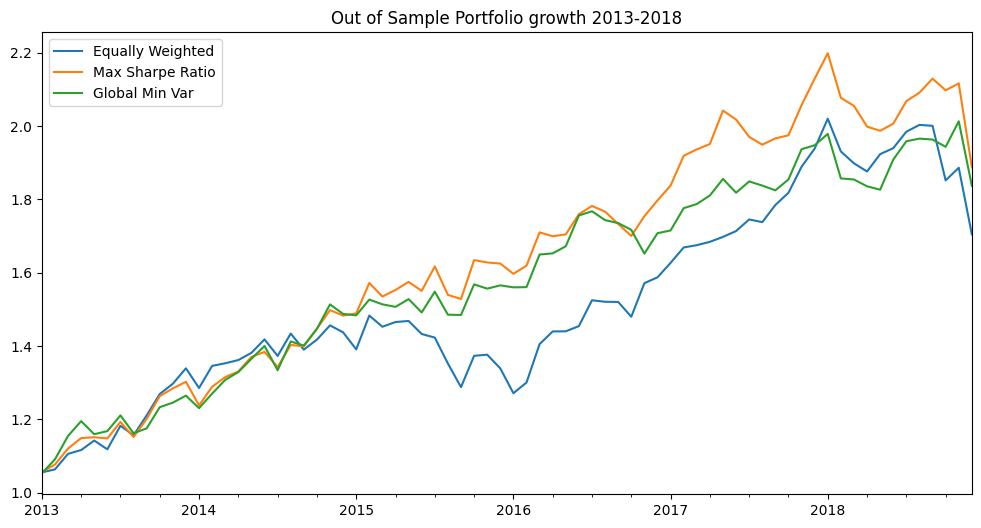

In [41]:
# Calculate Wealth Index
wealth_index = (1 + out_perf).cumprod()
ax = wealth_index.plot(figsize = (12,6), title = "Out of Sample Portfolio growth 2013-2018")

In [42]:
summary

,Annualized Return,Annualized Volatility,Sharpe Ratio
Equally Weighted,0.092969,0.116677,0.539682
Max Sharpe Ratio,0.111676,0.105782,0.772123
Global Min Var,0.106691,0.101773,0.753548


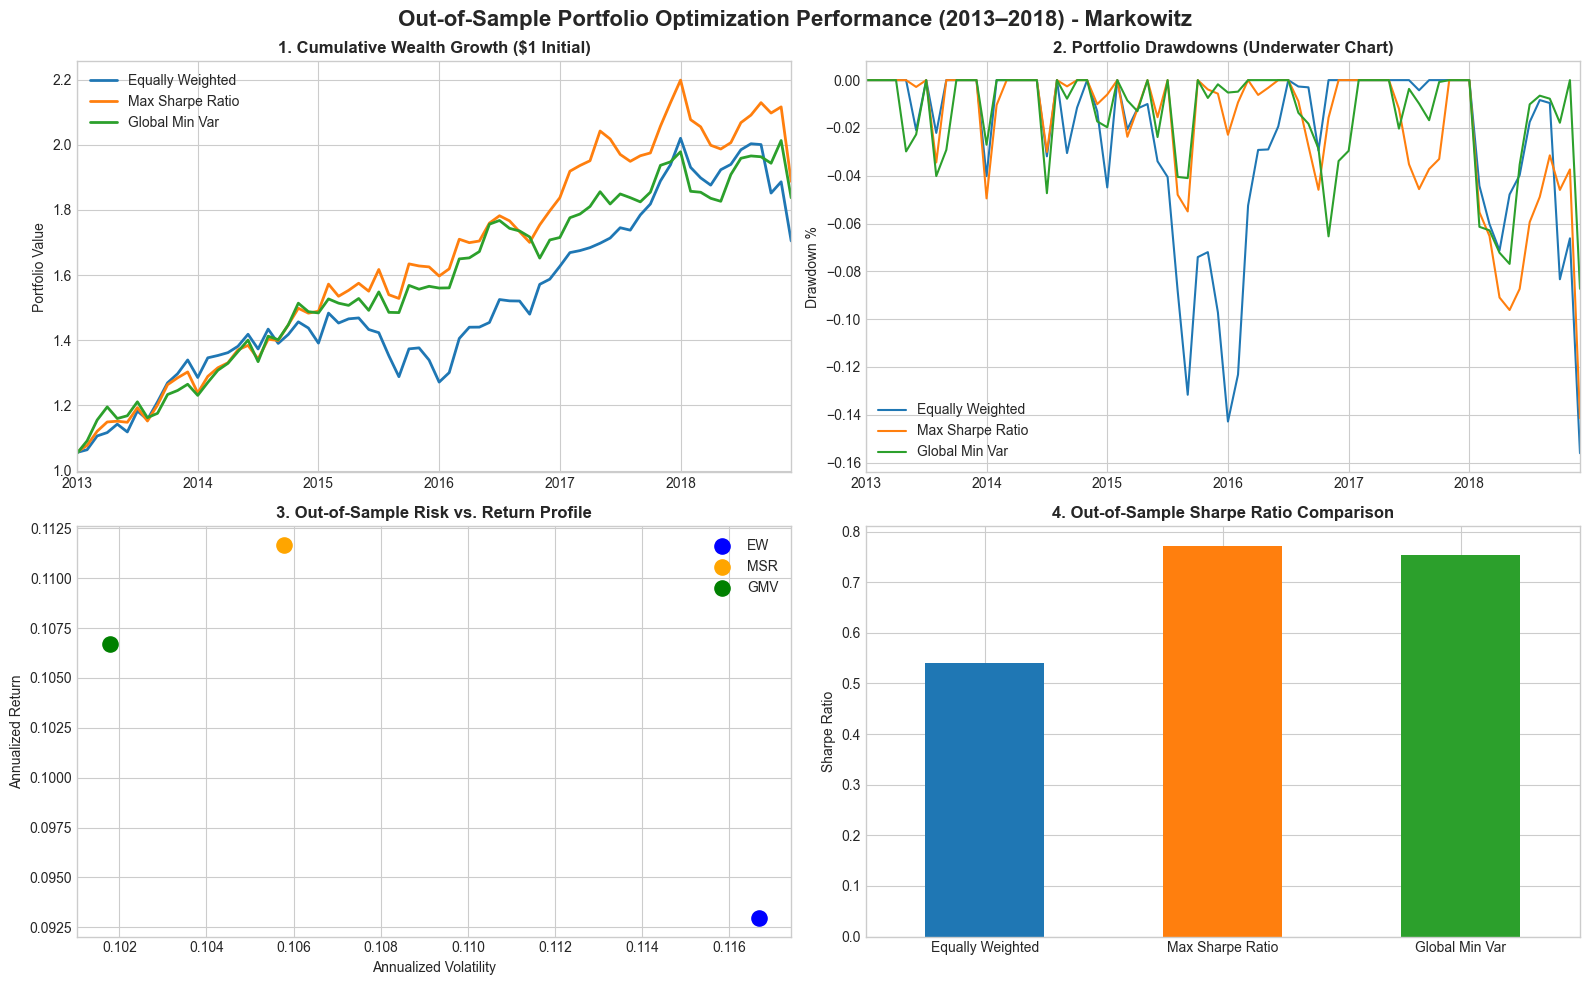

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Out-of-Sample Portfolio Optimization Performance (2013–2018) - Markowitz', fontsize=16, fontweight='bold')

# 1. Cumulative Growth (Wealth Index)
wealth_index = (1 + out_perf).cumprod()
wealth_index.plot(ax=axes[0, 0], linewidth=2)
axes[0, 0].set_title('1. Cumulative Wealth Growth ($1 Initial)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Portfolio Value')

# 2. Drawdown Chart
def drawdown(return_series):
    wealth = (1 + return_series).cumprod()
    peaks = wealth.cummax()
    return (wealth - peaks) / peaks

drawdowns = drawdown(out_perf)
drawdowns.plot(ax=axes[0, 1], linewidth=1.5)
axes[0, 1].set_title('2. Portfolio Drawdowns (Underwater Chart)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Drawdown %')

# 3. Risk vs. Return Scatter
axes[1, 0].scatter(ann_vol['Equally Weighted'], ann_ret['Equally Weighted'], color='blue', s=120, label='EW')
axes[1, 0].scatter(ann_vol['Max Sharpe Ratio'], ann_ret['Max Sharpe Ratio'], color='orange', s=120, label='MSR')
axes[1, 0].scatter(ann_vol['Global Min Var'], ann_ret['Global Min Var'], color='green', s=120, label='GMV')
axes[1, 0].set_title('3. Out-of-Sample Risk vs. Return Profile', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Annualized Volatility')
axes[1, 0].set_ylabel('Annualized Return')
axes[1, 0].legend()

# 4. Metric Comparison Bar Chart
summary['Sharpe Ratio'].plot(kind='bar', ax=axes[1, 1], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1, 1].set_title('4. Out-of-Sample Sharpe Ratio Comparison', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Sharpe Ratio')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("portfolio_dashboard.png", dpi=300)
plt.show()